In [1]:
import json
import argparse
import torch
from torch import nn
import wandb
from matplotlib import pyplot as plt
from src.data_loader import get_data_loaders
from src.loss import DifferentiableWeightedRadialFrequencyLoss
from src.model_diffusion import DiffusionModel
from src.model import Unet
from src.trainer import train_diffusion_model, train_diffusion_model_multisteps
from src.utils import count_parameters
from src.diffusion_utils import predict_start_from_noise, ddim_x0_estimate
from torch import optim
from sda.mcs import KolmogorovFlow

device = 'cuda'

In [3]:
%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=2

env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=2


In [4]:
model_linear_mid_training =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "psd",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_42/best_model.pth')
model_linear_mid_training.load_state_dict(checkpoint)
model_linear_mid_training.eval()

model_linear_end_training =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "psd",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_188/best_model.pth')
model_linear_end_training.load_state_dict(checkpoint)
model_linear_end_training.eval()

model_psd_mid_training =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "psd",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_40/best_model.pth')
model_psd_mid_training.load_state_dict(checkpoint)
model_psd_mid_training.eval()

model_psd =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "psd",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_189/best_model.pth')
model_psd.load_state_dict(checkpoint)
model_psd.eval()

model_psd_2steps =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "psd",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_189/best_model.pth')
model_psd_2steps.load_state_dict(checkpoint)
model_psd_2steps.eval()

models = {"PSD":model_psd, "Linear Convergence":model_psd_2steps}

In [48]:
model_psd =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "psd",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_189/epoch_21.pth')
model_psd.load_state_dict(checkpoint)

model_linear =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "linear",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_188/best_model.pth')
model_linear.load_state_dict(checkpoint)

model_cubic =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "linear",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_211/best_model.pth')
model_cubic.load_state_dict(checkpoint)

model_quadratic =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "linear",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_212/best_model.pth')
model_quadratic.load_state_dict(checkpoint)

model_piecewise =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "linear",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_213/best_model.pth')
model_piecewise.load_state_dict(checkpoint)

model_linear_0 =  DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "linear",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_42/best_model.pth')
model_linear_0.load_state_dict(checkpoint)

model_psd_plus = DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "linear",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_223/best_model.pth')
model_psd_plus.load_state_dict(checkpoint)

model_psd_plusplus = DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "linear",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_222/best_model.pth')
model_psd_plusplus.load_state_dict(checkpoint)

model_psd_plusminslogminustwo = DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "linear",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_238/best_model.pth')
model_psd_plusminslogminustwo.load_state_dict(checkpoint)

model_psd_plusplusplus = DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "linear",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_237/best_model.pth')
model_psd_plusplusplus.load_state_dict(checkpoint)

model_logminus5uniform = DiffusionModel(**{"dimension": 2,
        "dataSize": [64, 64],
        "condChannels": 2,
        "diffSchedule": "linear",
        "diffSteps": 100,
        "inferenceSamplingMode": "ddpm",
        "inferenceConditioningIntegration": "clean",
        "diffCondIntegration": "clean",
        "inferenceInitialSampling": "random",

        "x0_estimate_type": "mean"}).to(device)

checkpoint = torch.load('/mnt/SSD2/constantin/diffusion-multisteps/checkpoints/run_234/best_model.pth')
model_logminus5uniform.load_state_dict(checkpoint)

#models = {'Linear Schedule': model_linear_0, 'PSD-Plus Schedule': model_psd_plus}
#models = {'Linear Schedule': model_linear_end_training, 'PSD Schedule': model_psd_end_training, 
#          'PSD-Plus Schedule - Mid Training': model_psd_plus, 'PSD+++': model_psd_plusplusplus, 'PSD+MinLogMinus2': model_psd_plusminslogminustwo}
models = {'Linear Schedule': model_linear_end_training, 'PSDPlus Schedule': model_psd_plus,
          'LogMinus5Uniform Schedule': model_logminus5uniform}

In [10]:
data_params = {
        "dataset_name": "KolmogorovFlow",
        "data_path": "/mnt/SSD2/constantin/sda/data",
        "resolution": 64,
        "sequence_length": [2, 1],
        "trajectory_sequence_length": [64, 1],
        "frames_per_time_step": 1,
        "limit_trajectories_train": 819,
        "limit_trajectories_val": 102,
        "batch_size": 64
    }

train_loader, val_loader, traj_loader = get_data_loaders(data_params)

aaaa 819
aaaa 102
aaaa 102


In [50]:
statistics_eval_mode = {}

targets = []
conditions = []
estimates = []
estimates_clean = []

results = {model_name : {} for model_name in models} 

with torch.no_grad():
    for batch_idx, sample in enumerate(traj_loader):
        data = sample["data"].to(device)
        conditioning_frame = data[:, 0]
        target_frame = data[:, 1]

        for model_name in models:
            model = models[model_name]
            model.eval()
            
            _, x0_estimates_ancestor, inputs_ancestor = model(conditioning_frame, return_x0_estimate = True, input_type='ancestor', return_denoiser_inputs=True)
            _, x0_estimates_clean, inputs_clean = model(conditioning_frame, data=target_frame, return_x0_estimate = True, input_type='clean', return_denoiser_inputs=True)
            _, x0_estimates_clean_previous_step, inputs_clean_previous_step = model(conditioning_frame, data=target_frame, return_x0_estimate = True,
                                                    input_type='clean-previous-step', error_amount=torch.tensor(1e-3), return_denoiser_inputs=True)

            results[model_name]['ancestor'] = x0_estimates_ancestor
            results[model_name]['clean'] = x0_estimates_clean
            results[model_name]['clean_previous_step'] = x0_estimates_clean_previous_step

            results[model_name]['inputs_ancestor'] = inputs_ancestor
            results[model_name]['inputs_clean'] = inputs_clean
            results[model_name]['inputs_clean_previous_step'] = inputs_clean_previous_step

        if batch_idx == 0: break

### Construct Schedule with same high-noise weight but more weight on lower lows than PSD

In [5]:
import torch
import torch.nn.functional as F
import numpy as np

def betas_from_sqrtOneMinusAlphasCumprod(sqrtOneMinusAlphasCumprod: torch.Tensor) -> torch.Tensor:
    """
    Given sqrtOneMinusAlphasCumprod (shape [T] or [T, 1, 1, 1]), reconstructs a stable betas schedule.
    Ensures betas ∈ (0, 0.99].
    """
    # Flatten
    sqrtOneMinusAlphasCumprod = sqrtOneMinusAlphasCumprod.flatten().float()

    # 1. Compute alphas_cumprod
    alphas_cumprod = 1.0 - sqrtOneMinusAlphasCumprod ** 2  # shape [T]

    # Numerical safety
    alphas_cumprod = torch.clamp(alphas_cumprod, min=1e-8, max=1.0)

    # 2. Compute alphas from ratio
    alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
    alphas = alphas_cumprod / alphas_cumprod_prev
    alphas = torch.clamp(alphas, min=1e-8, max=1.0)

    # 3. Compute betas
    betas = 1.0 - alphas

    # 4. Clamp betas for stability
    betas = torch.clamp(betas, min=1e-8, max=0.999)

    return betas


Linear Schedule Clean: tensor(2.8139e-06) Ancestor: tensor(3.4438e-06)
PSDPlus Schedule Clean: tensor(1.1301e-06) Ancestor: tensor(1.2186e-06)
LogMinus5Uniform Schedule Clean: tensor(6.5465e-07) Ancestor: tensor(2.2906e-06)


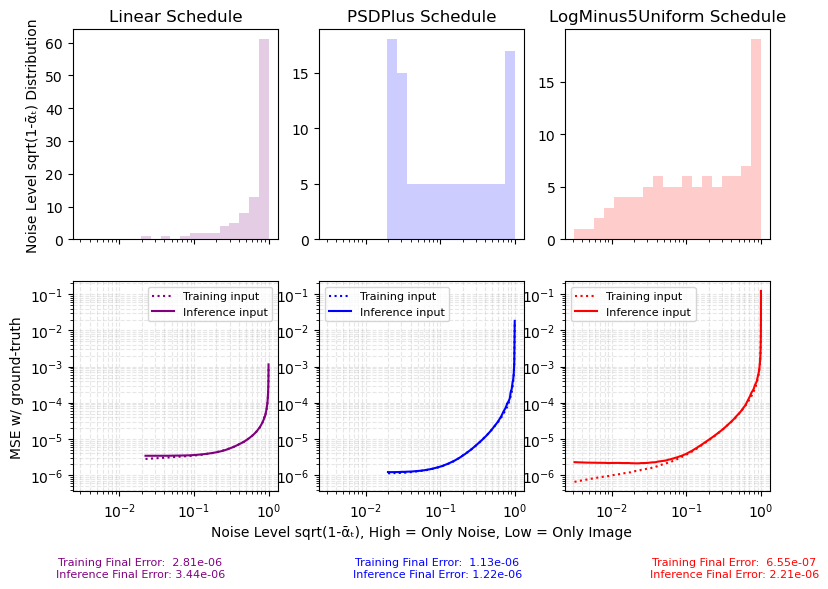

In [52]:
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(9, 6), sharex=True)

colors = ['purple', 'blue', 'red', 'green']

# --------------------
for i, model_name in enumerate(results):
    x0_estimates_ancestor = results[model_name]['ancestor']
    x0_estimates_clean = results[model_name]['clean']
    alphas = models[model_name].sqrtOneMinusAlphasCumprod.ravel().cpu()

    axes[0,i].hist(alphas, alpha=0.2, color=colors[i], bins=np.logspace(-2.5, 0, 20))

    # Compute MSE curves
    mse_clean = torch.tensor([
        torch.mean((est.cpu() - target_frame.cpu())**2) 
        for est in x0_estimates_clean
    ][::-1])

    mse_ancestor = torch.tensor([
        torch.mean((est.cpu() - target_frame.cpu())**2) 
        for est in x0_estimates_ancestor
    ][::-1])

    # Plot curves
    axes[1,i].plot(list(alphas.cpu()), mse_clean,
                   label="Training input", color=colors[i], linestyle='dotted')
    axes[1,i].plot(list(alphas.cpu()), mse_ancestor,
                   label="Inference input", color=colors[i])

    # Grid and title
    axes[1,i].grid(True, which='both', linestyle='--', alpha=0.3)
    axes[0,i].set_title(model_name)

    # --- Add final-value text under the title ---
    print(model_name, "Clean:", mse_clean[0], "Ancestor:", mse_ancestor[0])

    fig.text(
        0.2 + i*0.33,   # places 3 groups left→right
        0,            # slightly below suptitle
        f"Training Final Error:  {mse_clean[0]:.2e}\n"
        f"Inference Final Error: {mse_ancestor[i]:.2e}",
        ha='center',
        va='top',
        fontsize=8,
        color=colors[i]
    )

# --------------------

# Optional sharing
for i in range(3):
    axes[1,i].sharey(axes[1,-1])
    axes[1,i].legend(fontsize=8)
    

axes[0,0].set_xscale('log')
axes[1,0].set_yscale('log')
axes[1,0].set_ylabel('MSE w/ ground-truth')
axes[0,0].set_ylabel('Noise Level sqrt(1-ᾱₜ) Distribution')
axes[1,1].set_xlabel('Noise Level sqrt(1-ᾱₜ), High = Only Noise, Low = Only Image')

#fig.subplots_adjust(bottom=0.1)
#plt.tight_layout()
#plt.tight_layout(rect=[0, 0.12, 1, 1])
#plt.savefig("results/IntroducingExampleSchedulesPerf.pdf", bbox_inches="tight")
plt.show()


### Corresponding Long-Term Error for those models

In [21]:
from src.utils import evaluate_trajectory_vorticity, evaluate_trajectory_mse
longterm_results = {}

for name in models:

    model = models[name]
    results_model = evaluate_trajectory_vorticity(model, traj_loader, device, threshold=0.8)

    longterm_results[name] = results_model

In [11]:
from src.utils import evaluate_trajectory_mse
longterm_errors = {}

for name in models:

    model = models[name]
    results_model = evaluate_trajectory_mse(model, traj_loader, device, threshold=0.8)

    longterm_errors[name] = results_model

In [57]:
for name in longterm_errors:
    print(name, longterm_errors[name])

Linear Schedule {'errors_per_ts': array([3.35870959e-06, 7.65996697e-06, 1.35642413e-05, 2.25694166e-05,
       3.78506802e-05, 9.44072035e-05, 1.81585372e-04, 3.78608711e-04,
       8.26916119e-04, 1.16942381e-03, 1.47321582e-03, 1.69198599e-03,
       2.03635078e-03, 2.51927110e-03, 3.12311936e-03, 3.78593092e-03,
       4.65317152e-03, 5.86268166e-03, 7.45989406e-03, 9.43510025e-03,
       1.18618277e-02, 1.48566468e-02, 1.80573999e-02, 2.14673844e-02,
       2.54150098e-02, 2.97163399e-02, 3.49729853e-02, 4.15545767e-02,
       4.93476093e-02, 5.79080731e-02, 6.71991240e-02, 7.72227049e-02,
       8.81963558e-02, 1.00665249e-01, 1.15322027e-01, 1.32757019e-01,
       1.52779501e-01, 1.75814882e-01, 2.02823557e-01, 2.33375199e-01,
       2.67011546e-01, 3.03999111e-01, 3.44549596e-01, 3.87586549e-01,
       4.33888420e-01, 4.82898653e-01, 5.34895152e-01, 5.88409126e-01,
       6.40990078e-01, 6.91005766e-01, 7.39441693e-01, 7.87788302e-01,
       8.37938190e-01, 8.88235748e-01, 9.36

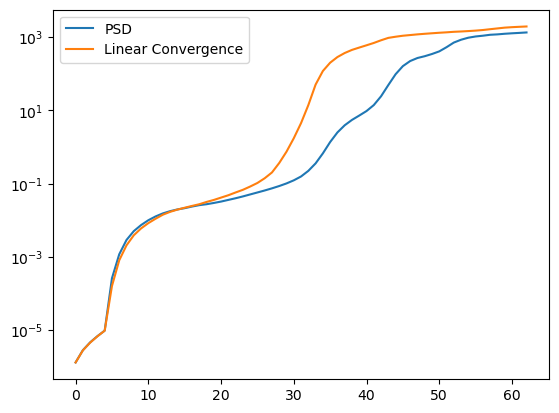

In [12]:
for name in longterm_errors:
    plt.plot(longterm_errors[name]['errors_per_ts'], label=name)
    plt.yscale('log')

plt.legend()

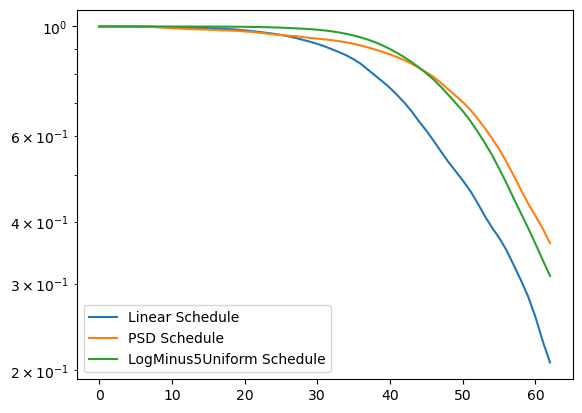

In [58]:
for name in longterm_results:
    plt.plot(longterm_results[name]['mean_correlations'], label=name)
    plt.yscale('log')

plt.legend()

Linear Schedule Clean: tensor(2.7883e-06) Ancestor: tensor(3.4706e-06)
PSD Schedule Clean: tensor(1.2583e-06) Ancestor: tensor(1.3311e-06)
PSD-Plus Schedule - Mid Training Clean: tensor(1.1329e-06) Ancestor: tensor(0.0003)


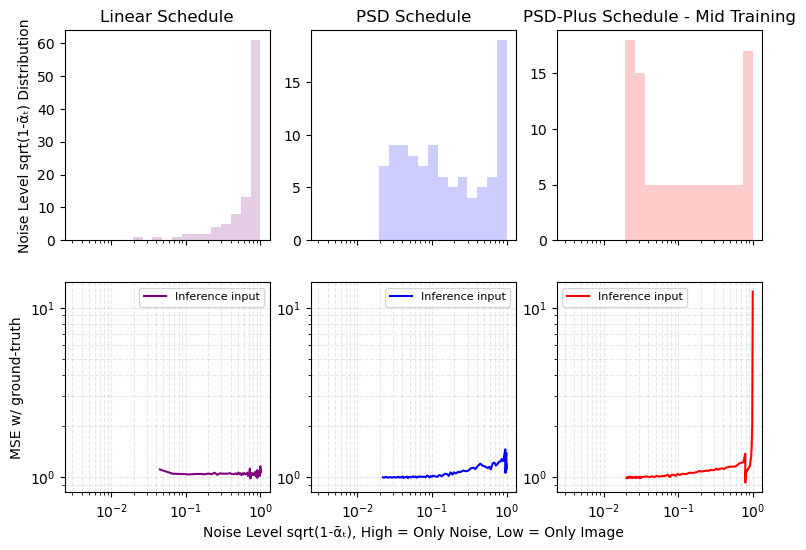

In [24]:
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(9, 6), sharex=True)

colors = ['purple', 'blue', 'red', 'green']

# --------------------
for i, model_name in enumerate(results):
    x0_estimates_ancestor = results[model_name]['ancestor']
    x0_estimates_clean = results[model_name]['clean']
    alphas = models[model_name].sqrtOneMinusAlphasCumprod.ravel().cpu()

    axes[0,i].hist(alphas, alpha=0.2, color=colors[i], bins=np.logspace(-2.5, 0, 20))

    # Compute MSE curves
    mse_clean = torch.tensor([
        torch.mean((est.cpu() - target_frame.cpu())**2) 
        for est in x0_estimates_clean
    ][::-1])

    mse_ancestor = torch.tensor([
        torch.mean((est.cpu() - target_frame.cpu())**2) 
        for est in x0_estimates_ancestor
    ][::-1])

    # Plot curves
    axes[1,i].plot(list(alphas.cpu()[1:]), mse_clean[1:]/mse_clean[:-1],
                   label="Inference input", color=colors[i])

    # Grid and title
    axes[1,i].grid(True, which='both', linestyle='--', alpha=0.3)
    axes[0,i].set_title(model_name)

    # --- Add final-value text under the title ---
    print(model_name, "Clean:", mse_clean[0], "Ancestor:", mse_ancestor[0])

# --------------------

# Optional sharing
for i in range(3):
    axes[1,i].sharey(axes[1,-1])
    axes[1,i].legend(fontsize=8)
    

axes[0,0].set_xscale('log')
axes[1,0].set_yscale('log')
axes[1,0].set_ylabel('MSE w/ ground-truth')
axes[0,0].set_ylabel('Noise Level sqrt(1-ᾱₜ) Distribution')
axes[1,1].set_xlabel('Noise Level sqrt(1-ᾱₜ), High = Only Noise, Low = Only Image')

#fig.subplots_adjust(bottom=0.1)
#plt.tight_layout()
#plt.tight_layout(rect=[0, 0.12, 1, 1])
#plt.savefig("results/IntroducingExampleSchedulesPerf.pdf", bbox_inches="tight")
plt.show()


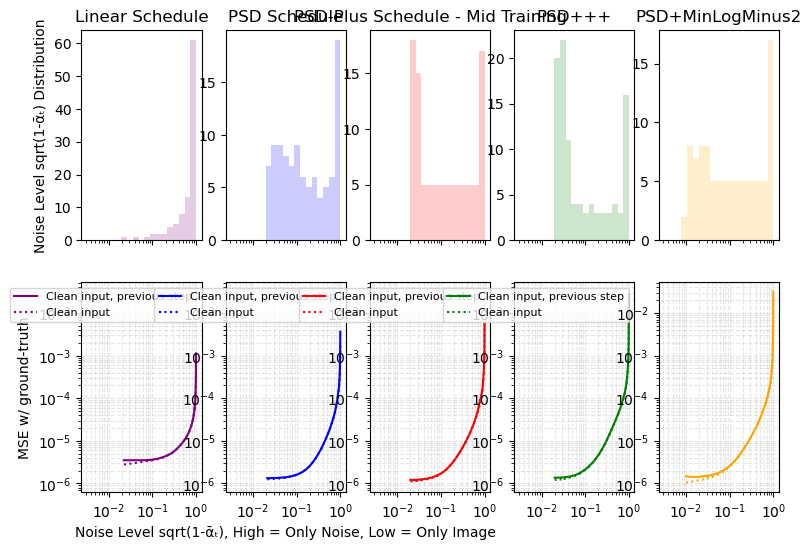

In [28]:
import numpy as np

fig, axes = plt.subplots(2, 5, figsize=(9, 6), sharex=True)

colors = ['purple', 'blue', 'red', 'green', 'orange']

# --------------------
for i, model_name in enumerate(results):
    x0_estimates_ancestor = results[model_name]['ancestor']
    x0_estimates_clean = results[model_name]['clean']
    x0_estimates_clean_prev_step = results[model_name]['clean_previous_step']
    alphas = models[model_name].sqrtOneMinusAlphasCumprod.ravel().cpu()

    axes[0,i].hist(alphas, alpha=0.2, color=colors[i], bins=np.logspace(-2.5, 0, 20))

    # Compute MSE curves
    mse_ancestor = torch.tensor([
        torch.mean((est.cpu() - target_frame.cpu())**2) 
        for est in x0_estimates_ancestor
    ][::-1])

    mse_clean = torch.tensor([
        torch.mean((est.cpu() - target_frame.cpu())**2) 
        for est in x0_estimates_clean
    ][::-1])

    # Plot curves
    axes[1,i].plot(list(alphas.cpu()), mse_ancestor,
                   label="Clean input, previous step", color=colors[i])
    
    axes[1,i].plot(list(alphas.cpu()), mse_clean,
                   label="Clean input", color=colors[i], linestyle='dotted')

    # Grid and title
    axes[1,i].grid(True, which='both', linestyle='--', alpha=0.3)
    axes[0,i].set_title(model_name)

    # --- Add final-value text under the title ---

# --------------------

# Optional sharing
for i in range(4):
    axes[1,i].sharey(axes[1,-1])
    axes[1,i].legend(fontsize=8)
    

axes[0,0].set_xscale('log')
axes[1,0].set_yscale('log')
axes[1,0].set_ylabel('MSE w/ ground-truth')
axes[0,0].set_ylabel('Noise Level sqrt(1-ᾱₜ) Distribution')
axes[1,1].set_xlabel('Noise Level sqrt(1-ᾱₜ), High = Only Noise, Low = Only Image')

#fig.subplots_adjust(bottom=0.1)
#plt.tight_layout()
#plt.tight_layout(rect=[0, 0.12, 1, 1])
#plt.savefig("results/IntroducingExampleSchedulesPerf.pdf", bbox_inches="tight")
plt.show()


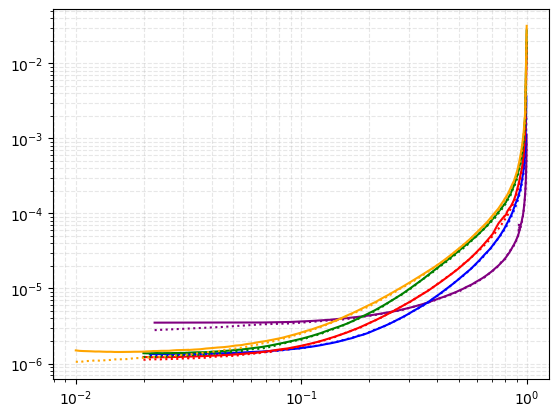

In [26]:
import numpy as np

#fig, axes = plt.subplots(1, figsize=(9, 6), sharex=True)

colors = ['purple', 'blue', 'red', 'green', 'orange']

# --------------------
for i, model_name in enumerate(results):
    x0_estimates_ancestor = results[model_name]['ancestor']
    x0_estimates_clean = results[model_name]['clean']
    x0_estimates_clean_prev_step = results[model_name]['clean_previous_step']
    alphas = models[model_name].sqrtOneMinusAlphasCumprod.ravel().cpu()

    # Compute MSE curves
    mse_ancestor = torch.tensor([
        torch.mean((est.cpu() - target_frame.cpu())**2) 
        for est in x0_estimates_ancestor
    ][::-1])

    mse_clean = torch.tensor([
        torch.mean((est.cpu() - target_frame.cpu())**2) 
        for est in x0_estimates_clean
    ][::-1])

    # Plot curves
    plt.plot(list(alphas.cpu()), mse_ancestor,
                   label="Ancestor input", color=colors[i])
    
    plt.plot(list(alphas.cpu()), mse_clean,
                   label="Clean input", color=colors[i], linestyle='dotted')

    # Grid and title
    plt.grid(True, which='both', linestyle='--', alpha=0.3)

    # --- Add final-value text under the title ---
plt.yscale('log')
plt.xscale('log')
# --------------------

#fig.subplots_adjust(bottom=0.1)
#plt.tight_layout()
#plt.tight_layout(rect=[0, 0.12, 1, 1])
#plt.savefig("results/IntroducingExampleSchedulesPerf.pdf", bbox_inches="tight")
plt.show()


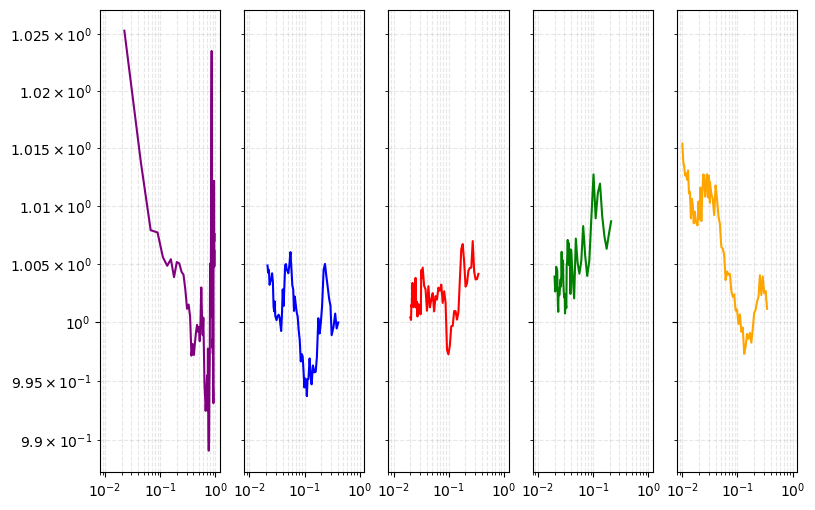

In [37]:
import numpy as np
import torch.nn.functional as F

fig, axes = plt.subplots(1, 5, figsize=(9, 6), sharex=True, sharey=True)

colors = ['purple', 'blue', 'red', 'green', 'orange']

# --------------------
for i, model_name in enumerate(results):
    x0_estimates_ancestor = results[model_name]['ancestor']
    x0_estimates_clean = results[model_name]['clean']
    x0_estimates_clean_prev_step = results[model_name]['clean_previous_step']
    alphas = models[model_name].sqrtOneMinusAlphasCumprod.ravel().cpu()

    # Compute MSE curves
    mse_ancestor = torch.tensor([
        torch.mean((est.cpu() - target_frame.cpu())**2) 
        for est in x0_estimates_clean_prev_step
    ][::-1])

    mse_clean = torch.tensor([
        torch.mean((est.cpu() - target_frame.cpu())**2) 
        for est in x0_estimates_clean
    ][::-1])

    # Plot curves
    axes[i].plot(list(alphas.cpu())[:71], np.convolve(np.array(mse_ancestor/mse_clean)[:80], 1/10*np.ones(10), mode="valid"),
                   label="Clean input, previous step", color=colors[i])

    # Grid and title
    axes[i].grid(True, which='both', linestyle='--', alpha=0.3)

    # --- Add final-value text under the title ---

axes[0].set_yscale('log')
axes[0].set_xscale('log')
#fig.subplots_adjust(bottom=0.1)
#plt.tight_layout()
#plt.tight_layout(rect=[0, 0.12, 1, 1])
#plt.savefig("results/IntroducingExampleSchedulesPerf.pdf", bbox_inches="tight")
plt.show()


In [38]:
from src.utils import compute_radial_psd_error

In [31]:
torch.mean((results['PSD Schedule']['clean'][10] - target_frame)**2)

tensor(0.0003, device='cuda:0')

In [43]:
torch.mean((results['PSD Schedule']['inputs_clean'][-1] - target_frame)**2)

tensor(0.0005, device='cuda:0')

tensor(99) tensor(0.0224)
tensor(99) tensor(0.0213)
tensor(99) tensor(0.0200)
tensor(99) tensor(0.0200)
tensor(82) tensor(0.0196)


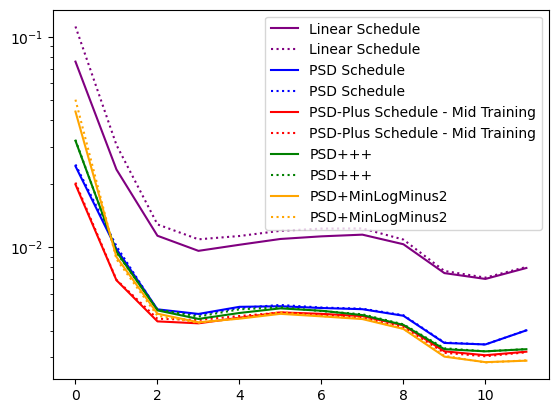

In [34]:
error = torch.mean((results['PSD Schedule']['clean'][10] - target_frame)**2)

alpha = 0.02

colors = ['purple', 'blue', 'red', 'green', 'orange']

for i, model in enumerate(results):
    alphas = torch.tensor(list(models[model].sqrtOneMinusAlphasCumprod.ravel())[::-1])
    closest_index = torch.argmin(torch.abs(alphas - alpha))
    print(closest_index, alphas[closest_index])
    plt.plot(compute_radial_psd_error(results[model]['clean'][closest_index], target_frame).values(), label=model, color=colors[i])
    plt.plot(compute_radial_psd_error(results[model]['clean_previous_step'][closest_index], target_frame).values(), label=model, linestyle='dotted', color=colors[i])

plt.legend()
plt.yscale('log')

tensor(96) tensor(0.0895)
tensor(56) tensor(0.0994)
tensor(50) tensor(0.0983)
tensor(50) tensor(0.0983)
tensor(99) tensor(0.0224)
tensor(99) tensor(0.0213)
tensor(99) tensor(0.0200)
tensor(82) tensor(0.0196)


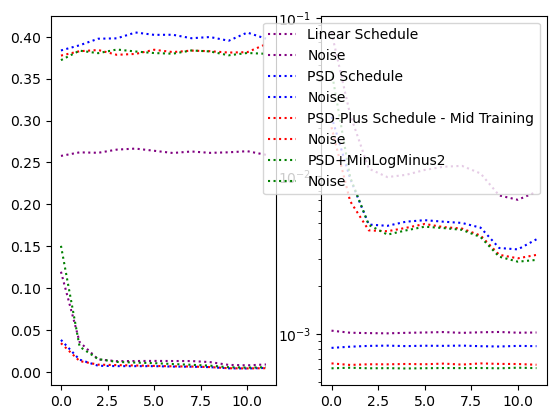

In [17]:
error = torch.mean((results['PSD Schedule']['clean'][10] - target_frame)**2)

alphas = [0.1, 0.02]

colors = ['purple', 'blue', 'red', 'green']

fig, axes = plt.subplots(1, len(alphas))

for j, alpha in enumerate(alphas):
    for i, model in enumerate(results):
        sqrtOneMinusAlphas = torch.tensor(list(models[model].sqrtOneMinusAlphasCumprod.ravel())[::-1])
        sqrtAlphas = torch.tensor(list(models[model].sqrtAlphasCumprod.ravel())[::-1])
        closest_index = torch.argmin(torch.abs(sqrtOneMinusAlphas - alpha))
        print(closest_index, sqrtOneMinusAlphas[closest_index])
        noise = torch.randn_like(target_frame) * sqrtOneMinusAlphas[closest_index]
        #plt.plot(compute_radial_psd_error(target_frame, torch.zeros_like(target_frame)).values(), label=model, color=colors[i])
        #plt.plot(compute_radial_psd_error(results[model]['clean'][closest_index], torch.zeros_like(target_frame)).values(), label=model, color=colors[i])
        axes[j].plot(compute_radial_psd_error(sqrtAlphas[closest_index] * (results[model]['clean'][closest_index] - target_frame),
                                            torch.zeros_like(target_frame)).values(), label=model, linestyle='dotted', color=colors[i])
        axes[j].plot(compute_radial_psd_error(sqrtOneMinusAlphas[closest_index] * noise,
                                            torch.zeros_like(target_frame)).values(), label="Noise", linestyle='dotted', color=colors[i])
        #break 
plt.legend()
plt.yscale('log')

### Hypothesis : Above a certain error to noise SNR, the model starts getting exposure bias ?

Not directly, since we see that for instance, Linear starts suffering from EB even before its error spectrum is above the noise spectrum. On the other hand, PSD Schedule doesn't suffer from EB even though the whole error spectrum is over the noise spectrum.

Intuition : Error done on parts of the spectrum which are already denoised will not propagate onto those parts of the spectrum. They will only propagate to parts of the spectrum which have not been denoised yet. 

In [ ]:
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(9, 6), sharex=True)

colors = ['purple', 'blue', 'red', 'green']

# --------------------
for i, model_name in enumerate(results):
    x0_estimates_ancestor = results[model_name]['ancestor']
    x0_estimates_clean = results[model_name]['clean']
    alphas = models[model_name].sqrtOneMinusAlphasCumprod.ravel().cpu()

    axes[0,i].hist(alphas, alpha=0.2, color=colors[i], bins=np.logspace(-2.5, 0, 20))

    # Compute MSE curves
    mse_clean_plus_error = torch.tensor([
        torch.mean((est.cpu() - target_frame.cpu())**2) 
        for est in x0_estimates_clean_plus_error
    ][::-1])

    mse_clean = torch.tensor([
        torch.mean((est.cpu() - target_frame.cpu())**2) 
        for est in x0_estimates_clean
    ][::-1])

    # Plot curves
    axes[1,i].plot(list(alphas.cpu()), mse_clean_plus_error,
                   label="Clean input, with error", color=colors[i])
    
    axes[1,i].plot(list(alphas.cpu()), mse_clean,
                   label="Clean input", color=colors[i], linestyle='dotted')

    # Grid and title
    axes[1,i].grid(True, which='both', linestyle='--', alpha=0.3)
    axes[0,i].set_title(model_name)

    # --- Add final-value text under the title ---

# --------------------

# Optional sharing
for i in range(3):
    axes[1,i].sharey(axes[1,-1])
    axes[1,i].legend(fontsize=8)
    

axes[0,0].set_xscale('log')
axes[1,0].set_yscale('log')
axes[1,0].set_ylabel('MSE w/ ground-truth')
axes[0,0].set_ylabel('Noise Level sqrt(1-ᾱₜ) Distribution')
axes[1,1].set_xlabel('Noise Level sqrt(1-ᾱₜ), High = Only Noise, Low = Only Image')

#fig.subplots_adjust(bottom=0.1)
#plt.tight_layout()
#plt.tight_layout(rect=[0, 0.12, 1, 1])
#plt.savefig("results/IntroducingExampleSchedulesPerf.pdf", bbox_inches="tight")
plt.show()


In [33]:
target = torch.concatenate((torch.logspace(-1.7, -1.5, 30),
                            torch.logspace(-1.5, -0.1, 55),
                            torch.logspace(-0.1, -0.0001, 15)))[4::5]

betas_0 = betas_from_sqrtOneMinusAlphasCumprod(target)

In [34]:
print(target)

tensor([0.0213, 0.0230, 0.0249, 0.0270, 0.0292, 0.0316, 0.0402, 0.0541, 0.0729,
        0.0983, 0.1325, 0.1786, 0.2407, 0.3244, 0.4373, 0.5893, 0.7943, 0.8483,
        0.9209, 0.9998])


In [35]:
print(betas_0)

tensor([4.5204e-04, 7.7844e-05, 9.1255e-05, 1.0693e-04, 1.2541e-04, 1.4693e-04,
        6.1280e-04, 1.3186e-03, 2.3986e-03, 4.3677e-03, 7.9691e-03, 1.4593e-02,
        2.6902e-02, 5.0222e-02, 9.6057e-02, 1.9304e-01, 4.3457e-01, 2.4017e-01,
        4.5826e-01, 9.9697e-01])


In [36]:
len(betas_0)

20

In [19]:
from src.diffusion_utils import cubic_beta_schedule, cosine_beta_schedule
betas = cosine_beta_schedule(timesteps=20)

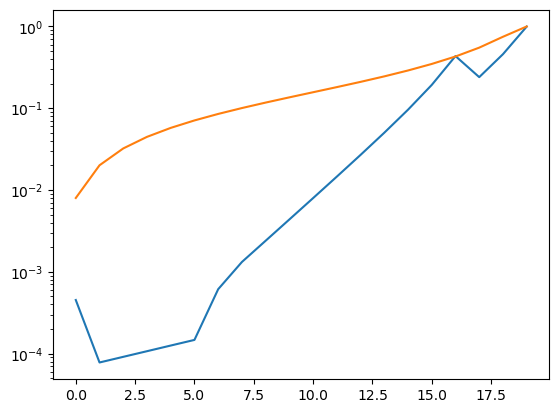

In [31]:
plt.plot(betas_0)
plt.plot(betas)
plt.yscale('log')